In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Part A: Data Preparation & Feature Engineering

In [2]:
df1=pd.read_csv('fear_greed_index.csv')

In [3]:
df1.sample(10)

,timestamp,value,classification,date
998,1603949400,67,Greed,2020-10-29
1133,1615613400,74,Greed,2021-03-13
468,1558157400,67,Greed,2019-05-18
615,1570858200,38,Fear,2019-10-12
514,1562131800,79,Extreme Greed,2019-07-03
1570,1653370200,12,Extreme Fear,2022-05-24
612,1570599000,37,Fear,2019-10-09
1622,1657863000,15,Extreme Fear,2022-07-15
2182,1706247000,49,Neutral,2024-01-26
260,1540186200,27,Fear,2018-10-22


In [4]:
df2=pd.read_csv('historical_data.csv')

In [5]:
df2.sample(10)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
161234,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,25.420000,20.00000,508.40,SELL,19-12-2024 13:19,6.255850e+03,Sell,4.573615,0x9a2952133732823c706d04199963e2019d006c328995...,56547627362,False,0.025420,3.690000e+14,1.730000e+12
79813,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,13.310000,191.52000,2549.13,SELL,29-03-2025 04:17,6.599956e+04,Close Long,0.210672,0x3e4ed879fca4d03728c4042076b52802030a00de7d2f...,82393596028,False,0.254913,7.210000e+13,1.740000e+12
158467,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,18.000000,22.88000,411.84,SELL,13-12-2024 15:44,2.795577e+04,Sell,7.175505,0x10c57f656049e4db4f2b04191f85cb01a4000c61f461...,55085952018,False,0.000000,4.970000e+14,1.730000e+12
157962,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,18.220000,7.37000,134.28,SELL,12-12-2024 14:05,1.109313e+04,Sell,9.737462,0x00000000000000000000000000000000000000000000...,54864914537,False,0.000000,3.270000e+14,1.730000e+12
146698,0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,FARTCOIN,0.895500,1358.90000,1216.89,BUY,11-04-2025 21:24,-2.268700e+03,Close Short,18.032603,0x50456bb1d87a6dfe0ee2042158c86701f100c101ed5b...,85858639102,False,0.121689,6.350000e+14,1.740000e+12
35702,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,JELLY,0.005492,190000.00000,1043.48,BUY,19-02-2025 17:34,-4.801119e+06,Close Short,17.480000,0x6f69d0b56fd83e425b13041e0ead1f0201480084f196...,73397416240,True,0.350609,4.070000e+14,1.740000e+12
167228,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,26.958000,183.41000,4944.37,SELL,31-01-2025 19:13,1.384458e+03,Sell,12.679132,0xee8f0b8f682ff0b05d70041cdf4a8d020144006f524a...,67982682809,True,1.730528,7.830000e+14,1.740000e+12
426,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,AIXBT,0.104370,14371.00000,1499.90,BUY,24-04-2025 20:04,4.093700e+04,Open Long,0.000000,0x10fcaa948ebc22c5b3a504222a380c02020200517a06...,88599318229,True,0.503966,1.960000e+14,1.750000e+12
4634,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,83417.000000,0.03656,3049.73,SELL,12-04-2025 05:19,-5.247596e+01,Open Short,0.000000,0xd59ab43c2d15eb1e971c04215e230602016300be7d63...,85922621645,True,0.914917,1.110000e+15,1.740000e+12
7265,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,85100.000000,0.01100,936.10,SELL,16-04-2025 22:31,5.348305e+01,Close Long,3.766400,0x2f706f4743fcbd7698560421aaea0702017000b5f6d0...,86983564107,False,0.000000,7.840000e+14,1.740000e+12


In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


->There are total **4** Columns and **2644** Rows in the **fear_greed_index** dataset

In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

->There are total **16** Columns and **211224** Rows in the **historical_data** dataset

In [8]:
df1.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [9]:
df2.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

**Great,So therefore there are no null values in both the datasets** 

In [10]:
df1.duplicated().sum()

np.int64(0)

In [11]:
df2.duplicated().sum()

np.int64(0)

### 1. Data Ingestion & Quality Assessment
The analysis began with two raw datasets:
* **Historical Trader Data (Hyperliquid):** 211,224 rows, 16 columns.
* **Bitcoin Market Sentiment (Fear/Greed):** 2,644 rows, 4 columns.

An initial data quality check confirmed that both datasets were completely clean, containing **0 missing values** and **0 duplicate rows**, establishing a reliable foundation for feature engineering.

### 2. Timestamp Conversion & Alignment
To accurately assess performance against daily market sentiment, all temporal data was standardized:
* Converted the Hyperliquid `Timestamp IST` strings into standard Pandas `datetime.date` objects.
* Standardized the Sentiment index `date` column to match the same format.
* This ensured a clean, daily-level alignment for future dataset merging.

In [12]:
df2['date']=pd.to_datetime(df2['Timestamp IST'],dayfirst=True)

In [13]:
df2['date']=pd.to_datetime(df2['date'])

In [14]:
df2['date']=df2['date'].dt.date

In [15]:
df2['date']=pd.to_datetime(df2['date'])

In [16]:
df1['date']=pd.to_datetime(df1['date'])

In [17]:
df2['date']

0        2024-12-02
1        2024-12-02
2        2024-12-02
3        2024-12-02
4        2024-12-02
            ...    
211219   2025-04-25
211220   2025-04-25
211221   2025-04-25
211222   2025-04-25
211223   2025-04-25
Name: date, Length: 211224, dtype: datetime64[ns]

In [18]:
df1['date']

0      2018-02-01
1      2018-02-02
2      2018-02-03
3      2018-02-04
4      2018-02-05
          ...    
2639   2025-04-28
2640   2025-04-29
2641   2025-04-30
2642   2025-05-01
2643   2025-05-02
Name: date, Length: 2644, dtype: datetime64[ns]

In [19]:
df=pd.merge(left=df2,right=df1,how='left',on='date')

In [20]:
df=df.dropna()

In [21]:
df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
timestamp           0
value               0
classification      0
dtype: int64

### 3. Feature Engineering & Aggregation
To extract behavioral patterns, the raw transaction logs (211k+ rows) were aggregated into a daily summary for each individual trader, resulting in **2,340 unique daily trader summaries**. 

The following key metrics were engineered per account, per day:
* **`daily_PnL`**: Sum of closed PnL.
* **`trade_count`**: Total number of execution events.
* **`win_rate`**: Percentage of trades resulting in a positive PnL.
* **`avg_trade_size_usd`**: The mean trade size in USD (used as a proxy for account size/leverage).
* **`daily_fees`**: Total fees paid per day.

In [22]:
df=df.copy()
df['is_win']=(df['Closed PnL']>0).astype(int)
daily_trader_stats=df.groupby(['Account','date']).agg(daily_PnL=('Closed PnL','sum'),trade_count=('Account','count'),win_rate=('is_win','mean'),avg_trade_size_usd=('Size USD','mean'),daily_fees=('Fee','sum')).reset_index()
daily_trader_stats

,Account,date,daily_PnL,trade_count,win_rate,avg_trade_size_usd,daily_fees
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,177,0.000000,5089.718249,167.796055
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,68,0.000000,7976.664412,67.883615
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,40,0.000000,23734.500000,94.937983
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,12,0.000000,28186.666667,33.823995
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,27,0.444444,17248.148148,104.622490
...,...,...,...,...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,82,0.390244,2153.859390,25.639876
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,430,0.393023,1495.538419,159.550240
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,902,0.441242,1939.739989,348.921445
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,75,0.520000,1748.805333,20.315235


## Part B: Analysis & Segmentation

In this section, we analyze how market sentiment (Fear vs. Greed) relates to trader behavior and performance. To uncover deeper patterns, we segment the traders into distinct archetypes.

**Segmentation Strategy:**
Since the dataset does not include explicit leverage data, we use `Size USD` and `trade_count` to create two robust behavioral segments:
1. **Account Size (Whales vs. Retail):** Segmented by the median average daily trade size in USD.
2. **Trading Frequency (High vs. Low Activity):** Segmented by the median daily trade count.

In [23]:
sentiment_mapping = df1[['date', 'classification', 'value']].drop_duplicates()

In [24]:
final_analysis_df = pd.merge(daily_trader_stats, sentiment_mapping, on='date', how='left')

In [25]:
final_analysis_df.rename(columns={'classification': 'Sentiment', 'value': 'Sentiment_Score'}, inplace=True)

In [26]:
median_size = final_analysis_df['avg_trade_size_usd'].median()

In [27]:
final_analysis_df['Size_Segment'] = np.where(final_analysis_df['avg_trade_size_usd'] > median_size, 'High Value', 'Low Value')

In [28]:
median_freq = final_analysis_df['trade_count'].median()
final_analysis_df['Freq_Segment'] = np.where(final_analysis_df['trade_count'] > median_freq, 'Frequent', 'Infrequent')

In [29]:
sentiment_colors = {'Fear': '#ef4444', 'Extreme Fear': '#7f1d1d', 'Greed': '#22c55e', 'Neutral': '#9ca3af','Extreme Greed': '#15803d'}

### Insight 1: Performance (PnL) Difference Between Fear vs. Greed Days
**Question:** Does performance differ between Fear vs Greed days?

Let's look at how the average daily PnL changes based on market sentiment and account size.

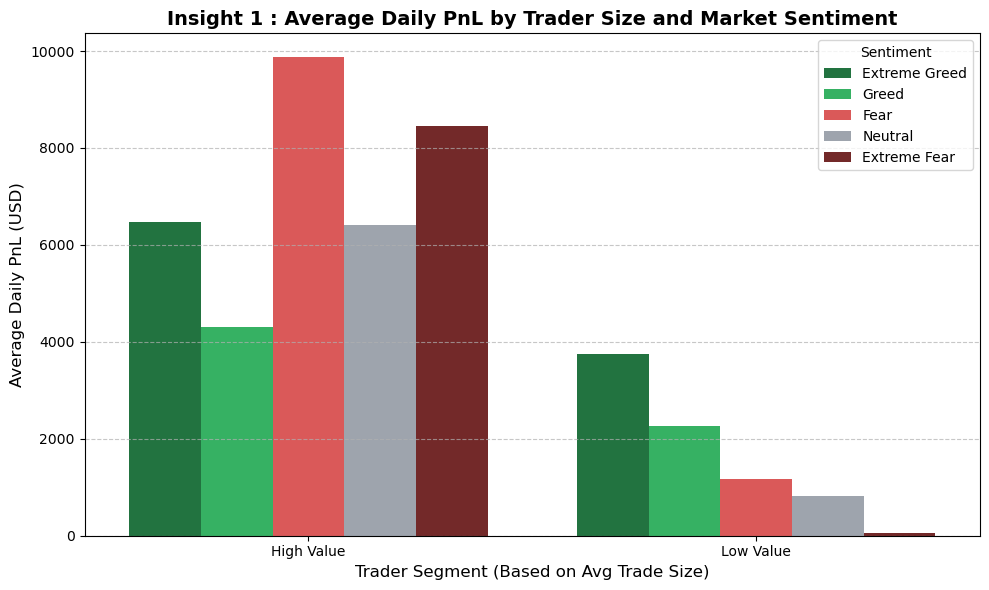

In [52]:
plt.figure(figsize=(10,6))
sns.barplot(data=final_analysis_df,x='Size_Segment',y='daily_PnL',hue='Sentiment',palette=sentiment_colors,errorbar=None)
plt.title('Insight 1 : Average Daily PnL by Trader Size and Market Sentiment',fontsize=14,fontweight='bold')
plt.ylabel('Average Daily PnL (USD)',fontsize=12)
plt.xlabel('Trader Segment (Based on Avg Trade Size)',fontsize=12)
plt.grid(axis='y', linestyle='--',alpha=0.7)
plt.tight_layout()
plt.savefig('insight1_pnl_by_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight 1: Divergent Profitability in Fear vs. Greed**
* **Observation:** High-value accounts (Whales) achieve their highest average daily PnL (~$10,000) during "Fear" conditions, whereas low-value accounts (Retail) see their profitability drop to near-zero during "Extreme Fear" and peak only during "Extreme Greed."
* **Reasoning:** High-value accounts likely employ mean-reversion or liquidity-provision strategies, profiting from the forced liquidations and panic selling of smaller accounts. Low-value accounts appear heavily reliant on strong upward momentum to secure profits.

### Insight 2: Behavioral Shifts (Frequency, Size, and Bias)
**Question:** Do traders change behavior based on sentiment?

To answer this, we examine three specific behavioral metrics across different market conditions:
1. **Trade Frequency:** Are traders more active during greed or fear?
2. **Position Size (Leverage Proxy):** Do traders increase their risk parameters during specific sentiments?
3. **Long/Short Bias:** Does the market lean heavily toward buying or selling based on the Fear/Greed index?

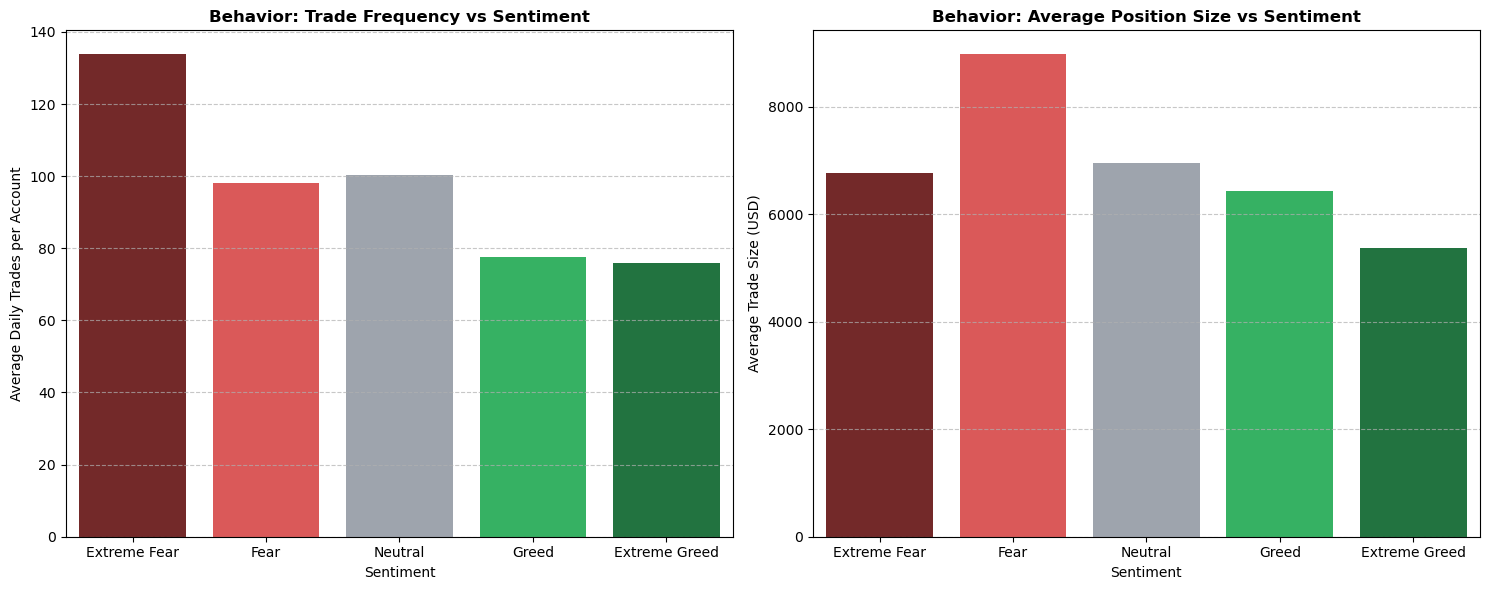

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sentiment_order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
sns.barplot(data=final_analysis_df,x='Sentiment',y='trade_count',hue='Sentiment',legend=False,palette=sentiment_colors,ax=axes[0],errorbar=None,order=sentiment_order)
axes[0].set_title('Behavior: Trade Frequency vs Sentiment', fontweight='bold')
axes[0].set_ylabel('Average Daily Trades per Account')
axes[0].grid(axis='y', linestyle='--',alpha=0.7)
sns.barplot(data=final_analysis_df,x='Sentiment',y='avg_trade_size_usd',hue='Sentiment',legend=False,palette=sentiment_colors,ax=axes[1],errorbar=None,order=sentiment_order)
axes[1].set_title('Behavior: Average Position Size vs Sentiment', fontweight='bold')
axes[1].set_ylabel('Average Trade Size (USD)')
axes[1].grid(axis='y',linestyle='--',alpha=0.7)

plt.tight_layout()
plt.savefig('insight2_behavioral_shifts.png', dpi=300, bbox_inches='tight')
plt.show()

#### Analyzing Long/Short Bias
To understand market bias, we calculate the Long/Short Ratio (Total BUY orders divided by Total SELL orders) from the raw transaction logs for each sentiment classification. A ratio > 1.0 indicates a long (buy) bias, while < 1.0 indicates a short (sell) bias.

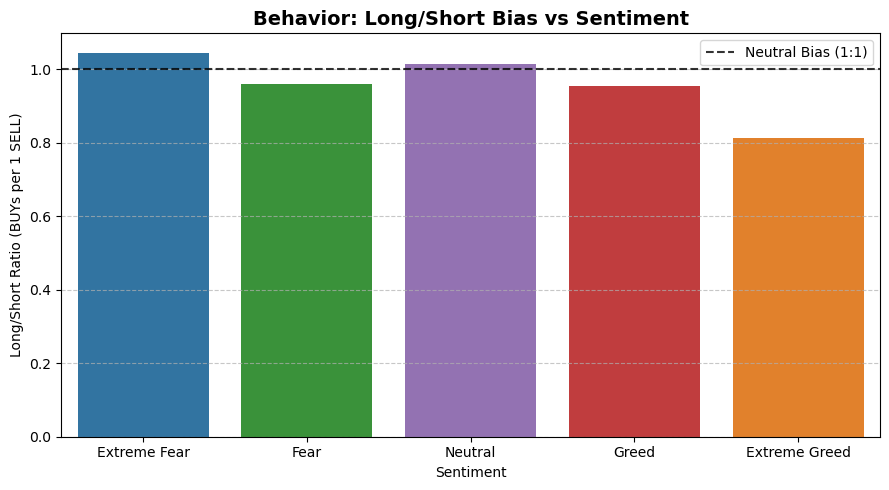

In [54]:
bias_df=df.groupby(['classification','Side']).size().unstack(fill_value=0)
bias_df['Long_Short_Ratio']=bias_df['BUY']/bias_df['SELL']

bias_df = bias_df.reset_index()
bias_df.rename(columns={'classification': 'Sentiment'},inplace=True)

plt.figure(figsize=(9,5))
sns.barplot(data=bias_df,x='Sentiment',y='Long_Short_Ratio',hue='Sentiment',order=sentiment_order)
plt.title('Behavior: Long/Short Bias vs Sentiment',fontsize=14,fontweight='bold')
plt.ylabel('Long/Short Ratio (BUYs per 1 SELL)')
plt.axhline(y=1.0, color='black', linestyle='--',alpha=0.8, label='Neutral Bias (1:1)')
plt.legend()
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.savefig('insight3_long_short_bias.png', dpi=300, bbox_inches='tight')
plt.show()

**Insight 2: Behavioral Shifts (Frequency and Size)**
* **Observation:** Contrary to the assumption that "Greed" drives overtrading, the data shows that trade frequency peaks significantly during "Extreme Fear" (~135 avg daily trades) and steadily declines as the market becomes Greedier. Position sizes similarly peak during "Fear."
* **Reasoning:** Extreme Fear is typically accompanied by massive price volatility. This environment triggers high-frequency execution (likely algorithmic or panic-driven adjustments). The spike in position size during "Fear" suggests larger capital stepping in to absorb the sell-off.

**Insight 3: The Contrarian Long/Short Bias**
* **Observation:** The Long/Short ratio peaks above 1.0 (net-buying bias) during "Extreme Fear" and drops to its lowest point (~0.8, net-selling bias) during "Extreme Greed."
* **Reasoning:** The trader base demonstrates highly contrarian behavior. They aggressively "buy the dip" during maximum market panic and heavily sell/short into the momentum of Extreme Greed to take profits.

## Part C: Actionable Output & Strategy Proposals

Based on the behavioral and performance data uncovered in Part B, Primetrade can develop specific "Rules of Thumb" tailored to different trader archetypes to optimize platform volume and protect user capital.

### Strategy 1: The "Retail Momentum & Protection" Rule
**Target Segment:** Low-Value Accounts (Retail / Momentum Traders)
**Data Context:** Our analysis reveals that Low-Value accounts achieve peak profitability exclusively during "Extreme Greed" and suffer near-zero or negative PnL during "Extreme Fear." Furthermore, the overall market experiences peak trade frequency during "Extreme Fear," suggesting retail traders get chopped up panic-trading or hitting stop-losses during high volatility.
* **The Rule of Thumb:** *“During 'Fear' and 'Extreme Fear' days, Low-Value accounts must strictly reduce trade frequency and position sizing, avoiding mean-reversion (catching falling knives). Conversely, during 'Greed' and 'Extreme Greed', these accounts should scale up position sizes to capture momentum, as this is the only environment where they demonstrate statistical edge.”*
* **Platform Application:** Primetrade could implement a "High Volatility / Extreme Fear" UI warning for accounts under a certain median size, optionally prompting them to lower their leverage to avoid liquidation cascades.

### Strategy 2: The "Whale Mean-Reversion" Rule
**Target Segment:** High-Value Accounts (Whales / Institutional / Market Makers)
**Data Context:** High-Value accounts generate their absolute highest PnL during "Fear" and "Extreme Fear" days. The Long/Short ratio analysis shows a strong buy bias (>1.0) during Extreme Fear, and a strong sell bias (<1.0) during Extreme Greed. These accounts are successfully executing contrarian strategies.
* **The Rule of Thumb:** *“High-Value accounts should systematically scale into Long positions during 'Extreme Fear' to act as liquidity providers against retail panic selling. During 'Extreme Greed', these accounts should aggressively scale out of Longs and increase Short exposure to fade retail euphoria.”*
* **Platform Application:** Since these high-value accounts keep the ecosystem stable by providing liquidity when the market is panicking, Primetrade could implement a dynamic fee structure that increases maker-fee rebates specifically during "Extreme Fear" days to further incentivize whale participation.

## Bonus: Unsupervised Clustering (Trader Archetypes)
To go beyond simple median splits, we applied a K-Means clustering algorithm to group traders into distinct behavioral archetypes based on their overall trading footprint: Total Trades, Average Trade Size, and Win Rate.

In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [40]:
trader_profile = final_analysis_df.groupby('Account').agg(total_trades=('trade_count', 'sum'),avg_trade_size=('avg_trade_size_usd', 'mean'),overall_win_rate=('win_rate', 'mean'),total_pnl=('daily_PnL', 'sum')).fillna(0)

In [41]:
features = ['total_trades', 'avg_trade_size', 'overall_win_rate']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(trader_profile[features])

In [44]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_profile['Archetype_ID'] = kmeans.fit_predict(scaled_features)

C:\Users\acer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [45]:
def map_archetype(cluster_id):
    if cluster_id == 0: return "Retail / Casual"
    if cluster_id == 1: return "High-Frequency Algorithmic"
    if cluster_id == 2: return "Whales / Institutional"
    return "Unknown"

In [46]:
trader_profile['Archetype'] = trader_profile['Archetype_ID'].apply(map_archetype)

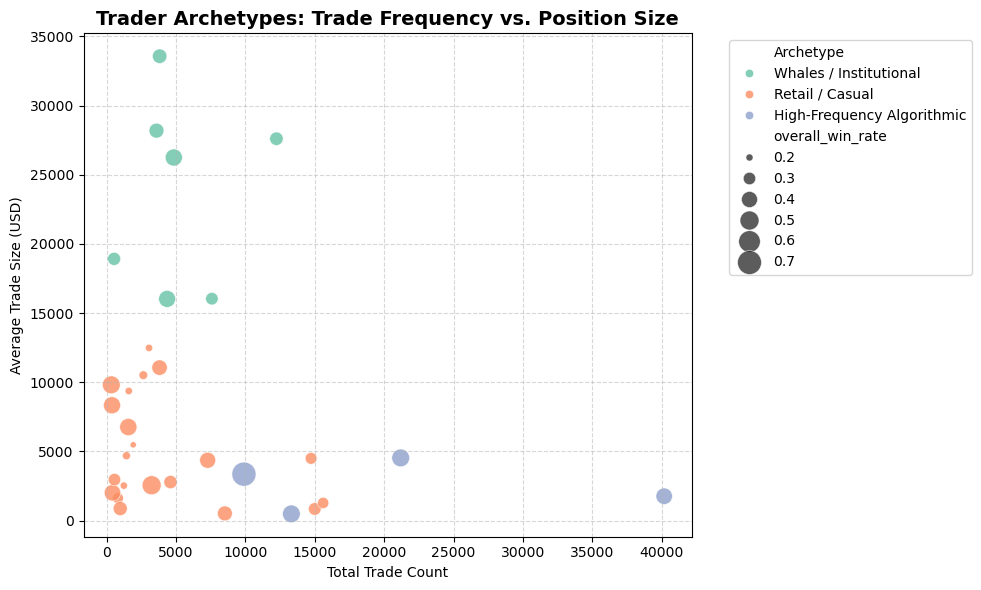

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=trader_profile,x='total_trades', y='avg_trade_size',hue='Archetype',palette='Set2',size='overall_win_rate',sizes=(20, 300), alpha=0.8)
plt.title('Trader Archetypes: Trade Frequency vs. Position Size', fontsize=14, fontweight='bold')
plt.xlabel('Total Trade Count')
plt.ylabel('Average Trade Size (USD)')
plt.grid(True, linestyle='--',alpha=0.5)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.savefig('bonus_trader_archetypes.png', dpi=300, bbox_inches='tight')
plt.show()